In [1]:
import pandas as pd
import geopandas as gpd
#import shapely
from shapely.geometry import Point
#from cartopy import crs
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
#import re
from shapely.wkt import loads
import numpy as np
#from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import altair as alt
#from scipy import ndimage
from PIL import Image
from plot_functions import plot_directional_ellipse_gdf, create_gif

In [2]:
commarea = gpd.read_file('south_chicago.geojson')
commarea.geometry = commarea.geometry.to_crs(epsg=26971)

parks_water = gpd.read_file('parks_water_no_mich_together.geojson')
parks_water = parks_water.to_crs(epsg='26971')

hom_1940 = gpd.read_file('homcide-locations_1940-1964.csv')
hom_1940.POINT_X = hom_1940.POINT_X.astype(float)
hom_1940.POINT_Y = hom_1940.POINT_Y.astype(float)
hom_1940['geometry'] = hom_1940.apply(lambda x: Point(x.POINT_X, x.POINT_Y),
                                      axis=1)
hom_1940 = gpd.GeoDataFrame(hom_1940, geometry='geometry', crs='EPSG:4326')
hom_1940 = hom_1940.to_crs(epsg=26971)
hom_1940.year = hom_1940.year.astype(float).astype(int)

hom_1870 = gpd.read_file('homicide-locations_1870-1930.csv')
hom_1870.x = hom_1870.x.astype(float)
hom_1870.y = hom_1870.y.astype(float)
hom_1870['geometry'] = hom_1870.apply(lambda a: Point(a.x, a.y),
                                      axis=1)
hom_1870 = gpd.GeoDataFrame(hom_1870, geometry='geometry', crs='EPSG:4326')
hom_1870 = hom_1870.to_crs(epsg='26971')
hom_1870.year = hom_1870.year.astype(float).astype(int)

hom_1940_south = gpd.sjoin(hom_1940, commarea, how='inner')
hom_1870_south = gpd.sjoin(hom_1870, commarea, how='inner')

hom_1965 = gpd.read_file('locs_homicide_post_65.geojson', #crs='EPSG:26971'
                         )
hom_1965.year = hom_1965.year.astype(int)
hom_1965.geometry = hom_1965.geometry.centroid
hom_1965 = hom_1965.to_crs(epsg=26971)
hom_1965_south = gpd.sjoin(hom_1965, commarea, how='inner')

commarea_west = gpd.read_file('westside.geojson')
commarea_west = commarea_west.to_crs(epsg='26971')
commarea_west.head()

hom_1870_west = gpd.sjoin(hom_1870, commarea_west, how="inner")
hom_1940_west = gpd.sjoin(hom_1940, commarea_west, how="inner")
hom_1965_west = gpd.sjoin(hom_1965, commarea_west, how="inner")

west_hom = pd.concat([hom_1870_west, hom_1940_west, hom_1965_west])

south_hom = pd.concat([hom_1870_south, hom_1940_south, hom_1965_south])

In [45]:
map_data = gpd.read_file('map_data.csv')
map_data.geometry = map_data.geometry.apply(loads)
map_data = gpd.GeoDataFrame(map_data, geometry='geometry', crs="EPSG:4326")
map_data = map_data.to_crs(epsg=26971)
map_data.head()
map_data.hom_ct = map_data.hom_ct.astype(float)
map_data.year = map_data.year.astype(int)
map_data['longest_gap'] = map_data['longest_gap'].replace('', pd.NA)
map_data['longest_gap'] = map_data.groupby('GRID_ID')['longest_gap'].ffill()
map_data['longest_gap'] = map_data['longest_gap'].astype(float)
map_data = map_data[map_data.GRID_ID != 'AF-4'] # excluding edgewater arson case

In [4]:
map_data_south = gpd.sjoin(map_data, commarea, 'inner')
map_data_south['longest_gap_ceiling'] = map_data_south.apply(
    lambda x: x['longest_gap'] if x['longest_gap'] <= 60 else 60,
    axis = 1
)

In [5]:
def difference(df, num_year):

    df_future = df.copy()
    df_future['year'] += num_year  # Shift years backwards to align future values
    df_future = df_future.rename(columns={'hom_ct': 'past_hom_ct'})  # Rename column for clarity

    # Merge original df with shifted df
    df_merged = df.merge(df_future[['GRID_ID', 'year', 'past_hom_ct']], 
                          on=['GRID_ID', 'year'], 
                          how='left')

    # Compute the difference (increase → poitive, decrease → negative)
    df_merged[f'difference_{num_year}year'] = df_merged['hom_ct'] - df_merged['past_hom_ct']
    df_merged.drop(columns=['past_hom_ct'], inplace=True)
    return df_merged

In [6]:
map_data = difference(map_data, 1)
map_data = difference(map_data, 5)
map_data = difference(map_data, 10)

In [7]:
map_data['difference_1year_min'] = map_data.groupby('GRID_ID')['difference_1year'].transform('min')
map_data['difference_5year_min'] = map_data.groupby('GRID_ID')['difference_5year'].transform('min')
map_data['difference_10year_min'] = map_data.groupby('GRID_ID')['difference_10year'].transform('min')

In [27]:
map_data.difference_1year_min.describe()

count    109880.000000
mean         -2.889024
std           2.564997
min         -16.000000
25%          -4.000000
50%          -2.000000
75%          -1.000000
max           0.000000
Name: difference_1year_min, dtype: float64

True


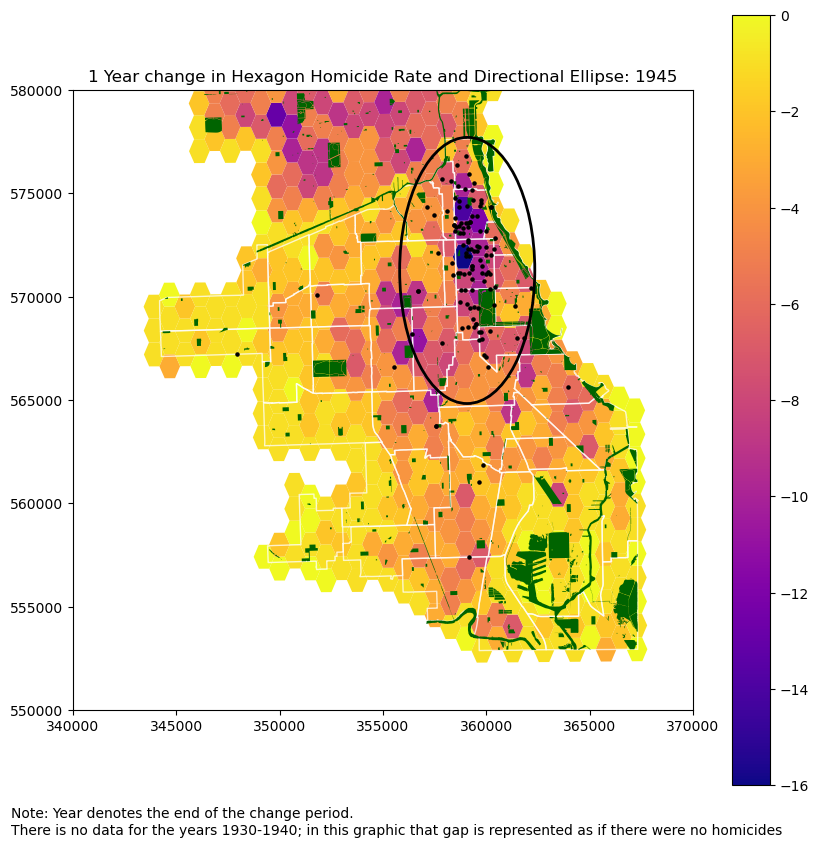

In [ ]:
# adding directional ellipse and hom rate change heatmap: south side test plot

x = 1945

fig, ax = plt.subplots(figsize=(10,10))

plt.ylim(550000, 580000)
plt.xlim(340000, 370000)

map_data[map_data.year==x].plot(column='difference_5year_min', 
                            cmap='plasma', 
                            legend=True, 
                            #vmin=-18,
                            #vmax=18,
                            linewidth=0.1,
                            #alpha=0.75,
                            ax=ax)

commarea.plot(facecolor="none", edgecolor="white", linewidth=1, ax=ax, alpha=0.75)
parks_water.plot(facecolor='darkgreen', ax=ax)

if (x in south_hom.year.unique()) and (south_hom.year.value_counts()[x] >= 2):
    print(south_hom.year.value_counts()[x] >= 5)
    plot_directional_ellipse_gdf(south_hom[south_hom['year']==x], n_std=2, ax=ax, edgecolor='black',
                                  facecolor='none',
                                 linewidth=2, alpha=1,
                                 )

plt.title(f'5 Year change in Hexagon Homicide Rate and Directional Ellipse: {x}')
ax.annotate('Note: Year denotes the end of the change period.\nThere is no data for the years 1930-1940; in this graphic that gap is represented as if there were no homicides',
            xy=(-0.1,-0.2),
            xycoords='axes fraction',
            fontsize=10)
plt.show()

In [44]:
most_recent = 1875

for x in range(1875, 2017):
    fig, ax = plt.subplots(figsize=(10,10))

    i = x

    plt.ylim(550000, 580000)
    plt.xlim(340000, 370000)

    if x not in map_data.year.unique():
        i = most_recent
        
    map_data[map_data.year==i].plot(column='difference_10year', 
                                cmap='plasma', 
                                legend=True, 
                                vmin=-18,
                                vmax=0,
                                linewidth=0.1,
                                #alpha=0.75,
                                ax=ax)

    
    commarea.plot(facecolor="none", edgecolor="white", linewidth=1, ax=ax, alpha=0.75)
    parks_water.plot(facecolor='darkgreen', ax=ax)
    plt.title(f'10 Year decrease in Hexagon Homicide Rate and Directional Ellipse: {x}')

    if (x in south_hom.year.unique()) and (south_hom.year.value_counts()[x] >= 2):
        print(south_hom.year.value_counts()[x] >= 5)
        plot_directional_ellipse_gdf(south_hom[south_hom['year']==x], n_std=2, ax=ax, edgecolor='black',
                                    facecolor='none',
                                    linewidth=2, alpha=1,
                                    )    
    ax.annotate('Note: Year denotes the end of the change period.\nThere is no data for the years 1930-1940; in this graphic that gap is represented as if there were no homicides',
            xy=(-0.1,-0.2),
            xycoords='axes fraction',
            fontsize=10)
    plt.savefig(f'change_dist_south/change_dist_south_{x}.png')
    print(f'change_dist_south/change_dist_south_{x}.png')
    plt.close()
    most_recent = i

change_dist_south/change_dist_south_1875.png
change_dist_south/change_dist_south_1876.png
change_dist_south/change_dist_south_1877.png
False
change_dist_south/change_dist_south_1878.png
False
change_dist_south/change_dist_south_1879.png
False
change_dist_south/change_dist_south_1880.png
True
change_dist_south/change_dist_south_1881.png
True
change_dist_south/change_dist_south_1882.png
True
change_dist_south/change_dist_south_1883.png
True
change_dist_south/change_dist_south_1884.png
True
change_dist_south/change_dist_south_1885.png
False
change_dist_south/change_dist_south_1886.png
True
change_dist_south/change_dist_south_1887.png
False
change_dist_south/change_dist_south_1888.png
True
change_dist_south/change_dist_south_1889.png
True
change_dist_south/change_dist_south_1890.png
True
change_dist_south/change_dist_south_1891.png
True
change_dist_south/change_dist_south_1892.png
True
change_dist_south/change_dist_south_1893.png
True
change_dist_south/change_dist_south_1894.png
True
chang

In [45]:
create_gif([f'change_dist_south/change_dist_south_{x}.png' for x in range(1875,2017)], 'change_dist_south/change_dist_south_gif_10year.gif')

GIF saved as change_dist_south/change_dist_south_gif_10year.gif in change_dist_south/change_dist_south_gif_10year.gif


In [50]:
most_recent = 1875

for x in range(1875, 2017):
    fig, ax = plt.subplots(figsize=(10,10))

    i = x

    plt.ylim(570000, 585000)
    plt.xlim(345000, 360000)

    if x not in map_data.year.unique():
        i = most_recent
        
    map_data[map_data.year==i].plot(column='difference_10year_min', 
                                cmap='plasma', 
                                legend=True, 
                                vmin=-18,
                                vmax=0,
                                linewidth=0.1,
                                #alpha=0.75,
                                ax=ax)

    
    commarea_west.plot(facecolor="none", edgecolor="white", linewidth=1, ax=ax, alpha=0.75)
    parks_water.plot(facecolor='darkgreen', ax=ax)
    plt.title(f'10 Year decrease in Hexagon Homicide Rate and Directional Ellipse: {x}')

    if (x in west_hom.year.unique()) and (west_hom.year.value_counts()[x] >= 2):
        print(west_hom.year.value_counts()[x] >= 5)
        plot_directional_ellipse_gdf(west_hom[west_hom['year']==x], n_std=2, ax=ax, edgecolor='black',
                                    facecolor='none',
                                    linewidth=2, alpha=1,
                                    )    
    ax.annotate('Note: Year denotes the end of the change period.\nThere is no data for the years 1930-1940; in this graphic that gap is represented as if there were no homicides',
            xy=(-0.1,-0.2),
            xycoords='axes fraction',
            fontsize=10)
    plt.savefig(f'change_dist_west/change_dist_west_{x}.png')
    print(f'change_dist_west/change_dist_west_{x}.png')
    plt.close()
    most_recent = i

True
change_dist_west/change_dist_west_1875.png
True
change_dist_west/change_dist_west_1876.png
True
change_dist_west/change_dist_west_1877.png
True
change_dist_west/change_dist_west_1878.png
True
change_dist_west/change_dist_west_1879.png
True
change_dist_west/change_dist_west_1880.png
True
change_dist_west/change_dist_west_1881.png
True
change_dist_west/change_dist_west_1882.png
True
change_dist_west/change_dist_west_1883.png
True
change_dist_west/change_dist_west_1884.png
True
change_dist_west/change_dist_west_1885.png
True
change_dist_west/change_dist_west_1886.png
True
change_dist_west/change_dist_west_1887.png
True
change_dist_west/change_dist_west_1888.png
True
change_dist_west/change_dist_west_1889.png
True
change_dist_west/change_dist_west_1890.png
True
change_dist_west/change_dist_west_1891.png
True
change_dist_west/change_dist_west_1892.png
True
change_dist_west/change_dist_west_1893.png
True
change_dist_west/change_dist_west_1894.png
True
change_dist_west/change_dist_west_1

In [51]:
create_gif([f'change_dist_west/change_dist_west_{x}.png' for x in range(1875, 2017)], 'change_dist_west/change_dist_west_gif_10year_static.gif')

GIF saved as change_dist_west/change_dist_west_gif_10year_static.gif in change_dist_west/change_dist_west_gif_10year_static.gif


In [8]:
map_data.head()

,field_1,GRID_ID,year,hom_ct,bldg_ct,hom_rt,geometry,last_wave_end,longest_gap,difference_1year,difference_5year,difference_10year,difference_1year_min,difference_5year_min,difference_10year_min
0,0,AJ-37,1874,0.0,0.0,,"POLYGON ((359530.736 553447.796, 359285.268 55...",,NaN,NaN,NaN,NaN,0.0,0.0,0.0
1,1,AK-37,1874,0.0,4.198222705933977,0.0,"POLYGON ((360286.292 552876.188, 360040.864 55...",,NaN,NaN,NaN,NaN,-1.0,-1.0,-1.0
2,2,AL-37,1874,0.0,0.001777294066012,0.0,"POLYGON ((361032.151 553460.401, 360786.804 55...",1996.0,21.0,NaN,NaN,NaN,-3.0,-3.0,-5.0
3,3,AM-37,1874,0.0,0.0,,"POLYGON ((361787.828 552888.949, 361542.521 55...",,NaN,NaN,NaN,NaN,-1.0,-1.0,-1.0
4,4,AN-37,1874,0.0,0.0,,"POLYGON ((362533.566 553473.32, 362288.34 5528...",,NaN,NaN,NaN,NaN,-1.0,-1.0,-1.0


In [17]:
plt.close()

<Axes: >

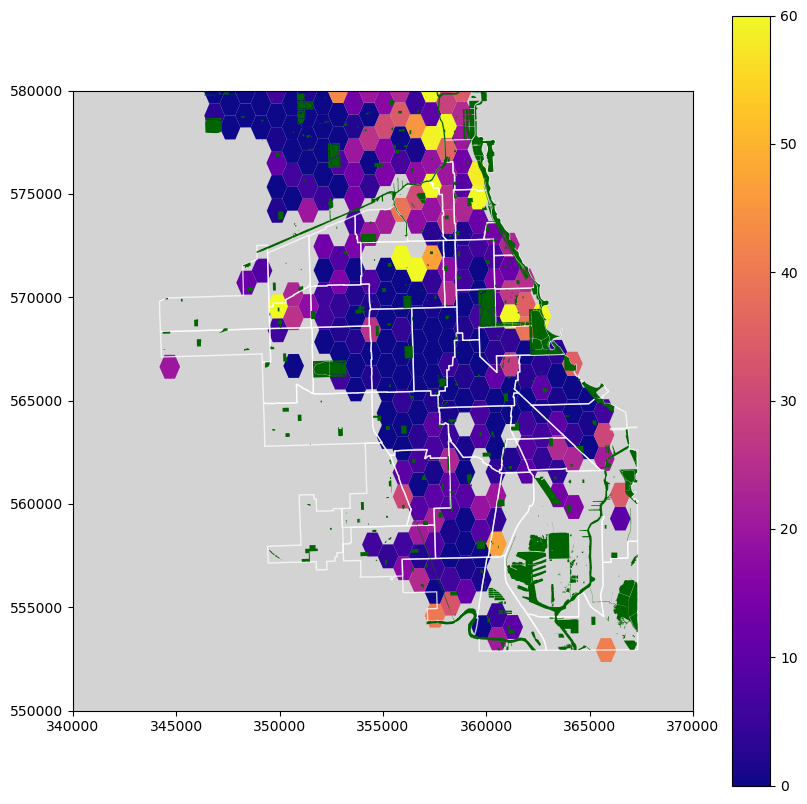

In [13]:
fig, ax = plt.subplots(figsize=(10,10))
#fig.set_facecolor('lightgray')
ax.set_facecolor('lightgray')

plt.ylim(550000, 580000)
plt.xlim(340000, 370000)

map_data[map_data['year']==1955].plot(column='longest_gap',
              cmap='plasma', 
                legend=True, 
                vmin=0,
                vmax=60,
                linewidth=0.1,
                #alpha=0.75,
                ax=ax)

commarea.plot(facecolor="none", edgecolor="white", linewidth=1, ax=ax, alpha=0.75)
parks_water.plot(facecolor='darkgreen', ax=ax)

In [24]:
comm_chart = alt.Chart(commarea).mark_geoshape(fill='none',
    stroke='black',
    strokeWidth=0.5).encode(
        opacity=alt.value(1)
    ).project(type='identity', reflectY=True)

comm_chart

alt.Chart(...)

In [29]:
last_wave_end_south = alt.Chart(map_data_south[map_data_south['year']==1950].dropna(subset=['longest_gap']),
                           title=alt.Title('Longest Gap since homicide wave - South Side',
                                           )).mark_geoshape().encode(
    tooltip=['GRID_ID', 'longest_gap','last_wave_end'],
    color='longest_gap_ceiling:Q',
    opacity=alt.value(1)
).project(type='identity', reflectY=True).interactive()

last_wave_end_south = alt.layer(comm_chart, last_wave_end_south)

last_wave_end_south

alt.LayerChart(...)

In [39]:
westside = gpd.read_file('westside.geojson')
westside = westside.to_crs(epsg=26971)

In [33]:
map_data.head()

,field_1,GRID_ID,year,hom_ct,bldg_ct,hom_rt,geometry,last_wave_end,longest_gap,difference_1year,difference_5year,difference_10year,difference_1year_min,difference_5year_min,difference_10year_min
0,0,AJ-37,1874,0.0,0.0,,"POLYGON ((359530.736 553447.796, 359285.268 55...",,NaN,NaN,NaN,NaN,0.0,0.0,0.0
1,1,AK-37,1874,0.0,4.198222705933977,0.0,"POLYGON ((360286.292 552876.188, 360040.864 55...",,NaN,NaN,NaN,NaN,-1.0,-1.0,-1.0
2,2,AL-37,1874,0.0,0.001777294066012,0.0,"POLYGON ((361032.151 553460.401, 360786.804 55...",1996.0,21.0,NaN,NaN,NaN,-3.0,-3.0,-5.0
3,3,AM-37,1874,0.0,0.0,,"POLYGON ((361787.828 552888.949, 361542.521 55...",,NaN,NaN,NaN,NaN,-1.0,-1.0,-1.0
4,4,AN-37,1874,0.0,0.0,,"POLYGON ((362533.566 553473.32, 362288.34 5528...",,NaN,NaN,NaN,NaN,-1.0,-1.0,-1.0


In [46]:
map_data_west = gpd.sjoin(map_data, westside, 'inner')

In [41]:
comm_chart_west = alt.Chart(westside).mark_geoshape(fill='none',
    stroke='black',
    strokeWidth=0.5).encode(
        opacity=alt.value(1)
    ).project(type='identity', reflectY=True)

comm_chart_west

alt.Chart(...)

In [50]:
map_data_west['longest_gap'] = map_data_west.groupby('GRID_ID')['longest_gap'].ffill()
map_data_west['longest_gap'] = map_data_west['longest_gap'].astype(float)
map_data_west['longest_gap_ceiling'] = map_data_west.apply(
    lambda x: x['longest_gap'] if x['longest_gap'] <= 60 else 60,
    axis = 1
)
map_data_west.head()

,field_1,GRID_ID,year,hom_ct,bldg_ct,hom_rt,geometry,last_wave_end,longest_gap,index_right,name,longest_gap_ceiling
281,281,W-20,1874,0.0,0.0,,"POLYGON ((349639.143 572443.51, 349393.573 571...",,NaN,0,westside,60.0
282,282,X-20,1874,0.0,0.0,,"POLYGON ((350383.772 573026.643, 350138.284 57...",,NaN,0,westside,60.0
283,283,Y-20,1874,0.0,0.0,,"POLYGON ((351136.566 572454.081, 350891.117 57...",,NaN,0,westside,60.0
284,284,Z-20,1874,0.0,0.0,,"POLYGON ((351881.075 573037.371, 351635.707 57...",,NaN,0,westside,60.0
297,297,W-19,1874,0.0,0.0,,"POLYGON ((349631.1 573599.283, 349385.571 5730...",,NaN,0,westside,60.0


In [52]:
last_wave_end_west = alt.Chart(map_data_west[map_data_west['year']==1950].dropna(subset=['longest_gap']),
                           title=alt.Title('Longest Gap since homicide wave - West Side',
                                           )).mark_geoshape().encode(
    tooltip=['GRID_ID', 'longest_gap','last_wave_end'],
    color='longest_gap_ceiling:Q',
    opacity=alt.value(1)
).project(type='identity', reflectY=True).interactive()

last_wave_end_west = alt.layer(comm_chart_west, last_wave_end_west)

last_wave_end_west

alt.LayerChart(...)

In [53]:
last_wave_end_south.save('viz/last_wave_end_south.html')
last_wave_end_west.save('viz/last_wave_end_west.html')

In [62]:
import os
import re

def patch_altair_html(html, chart_id):
    """Modifies an Altair HTML export so it has a unique chart ID and embeds correctly."""
    # Change the div ID
    html = re.sub(r'<div id="vis">', f'<div id="vis-{chart_id}">', html)
    # Change the vegaEmbed call to target the unique ID
    html = re.sub(r"vegaEmbed\('#vis'", f"vegaEmbed('#vis-{chart_id}'", html)
    return html

def merge_html_files(html_files, output_file, title="Merged Visualizations"):
    """Merges multiple Altair-exported HTML files into one page with isolated charts."""
    
    merged_content = f"""<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>{title}</title>
    <style>
        body {{ font-family: Arial, sans-serif; margin: 20px; }}
        h1 {{ text-align: center; }}
        .viz-container {{ margin-bottom: 40px; border: 1px solid #ccc; padding: 10px; }}
    </style>
    <!-- Load Vega libraries once -->
    <script src="https://cdn.jsdelivr.net/npm/vega@5"></script>
    <script src="https://cdn.jsdelivr.net/npm/vega-lite@5.20.1"></script>
    <script src="https://cdn.jsdelivr.net/npm/vega-embed@6"></script>
</head>
<body>
    <h1>{title}</h1>
"""

    for i, html_file in enumerate(html_files):
        with open(html_file, "r", encoding="utf-8") as f:
            raw_html = f.read()
            patched_html = patch_altair_html(raw_html, chart_id=i)
            merged_content += f"""
    <div class="viz-container">
        <h2>Visualization {i + 1}</h2>
        {patched_html}
    </div>
"""

    merged_content += "\n</body>\n</html>"

    with open(output_file, "w", encoding="utf-8") as f:
        f.write(merged_content)

    print(f"Merged HTML saved as {output_file}")

In [66]:
import re

def extract_spec_block(html):
    """Extracts the Vega-Lite spec object from 'var spec = {...};' in Altair-exported HTML."""
    match = re.search(r'var spec\s*=\s*({.*?})\s*;\s*', html, re.DOTALL)
    if not match:
        return None
    return match.group(1)

def merge_altair_html_files(html_files, output_file, title="Merged Visualizations"):
    """Safely merges Altair-exported HTML files by deferring vegaEmbed calls until load."""
    
    header = f"""<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <title>{title}</title>
  <style>
    body {{ font-family: Arial, sans-serif; margin: 20px; }}
    h1 {{ text-align: center; }}
    .viz-container {{ margin-bottom: 40px; border: 1px solid #ccc; padding: 10px; }}
  </style>
  <script src="https://cdn.jsdelivr.net/npm/vega@5"></script>
  <script src="https://cdn.jsdelivr.net/npm/vega-lite@5.20.1"></script>
  <script src="https://cdn.jsdelivr.net/npm/vega-embed@6"></script>
</head>
<body>
  <h1>{title}</h1>
"""

    chart_divs = []
    chart_specs = []

    for i, html_file in enumerate(html_files):
        with open(html_file, 'r', encoding='utf-8') as f:
            html = f.read()
        spec = extract_spec_block(html)
        if not spec:
            raise ValueError(f"Could not extract Vega spec from {html_file}")
        chart_divs.append(f'<div class="viz-container"><h2>Visualization {i+1}</h2><div id="vis-{i}"></div></div>')
        chart_specs.append(f'vegaEmbed("#vis-{i}", {spec});')

    footer = f"""
<script>
window.onload = function() {{
    {"".join(chart_specs)}
}};
</script>
</body>
</html>
"""

    merged_html = header + "\n".join(chart_divs) + footer

    with open(output_file, 'w', encoding='utf-8') as f:
        f.write(merged_html)

    print(f"Merged HTML saved to: {output_file}")

In [55]:
file_list = ['viz/last_wave_end_south.html',
             'viz/last_wave_end_west.html']

In [67]:
merge_altair_html_files(file_list, 'viz/last_wave_end_merged.html', 'Last Wave End - West and South Side')

Merged HTML saved to: viz/last_wave_end_merged.html
